# Smart Quiz with Vectorized Neural Network

This is a small Smart Quiz difficulty-adaptation model using **vectorized NumPy operations**

## 1 - Packages


In [12]:
import random
import os
import csv
import numpy as np
import matplotlib.pyplot as plt

## 2 - Vectorized Neural Network
This network follows the logic: **2 -> 8 -> 1** with a continuous difficulty output in `[0.0, 1.0]`.
- Input: correctness signal `[1,0]` or `[0,1]`
- Output: predicted difficulty score
- All forward/backward layer math is vectorized with NumPy

In [13]:
class SimpleNN:
    def __init__(self, input_size, hidden_size, output_size):
        self.W1 = np.random.uniform(-1, 1, size=(hidden_size, input_size))
        self.b1 = np.random.uniform(-1, 1, size=(hidden_size, 1))
        self.W2 = np.random.uniform(-1, 1, size=(output_size, hidden_size))
        self.b2 = np.random.uniform(-1, 1, size=(output_size, 1))

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def sigmoid_deriv(self, s):
        return s * (1 - s)

    def forward(self, x):
        x_col = np.asarray(x, dtype=float).reshape(-1, 1)
        self.last_x = x_col
        self.z1 = self.W1 @ x_col + self.b1
        self.a1 = self.sigmoid(self.z1)
        self.z2 = self.W2 @ self.a1 + self.b2
        self.a2 = self.sigmoid(self.z2)
        return self.a2.ravel()

    def backward(self, x, y, lr=0.1):
        y_col = np.asarray(y, dtype=float).reshape(-1, 1)

        dz2 = self.a2 - y_col
        dW2 = dz2 @ self.a1.T
        db2 = dz2

        dz1 = (self.W2.T @ dz2) * self.sigmoid_deriv(self.a1)
        dW1 = dz1 @ self.last_x.T
        db1 = dz1

        self.W2 -= lr * dW2
        self.b2 -= lr * db2
        self.W1 -= lr * dW1
        self.b1 -= lr * db1

## 3 - Data + Helper Functions
- Loads questions from `questions.csv` (`level,question,answer`)
- Falls back to defaults if CSV is missing/invalid
- Adds pretraining and model save/load (`smart_quiz_model.npz`)
- Uses anti-repetition question sampling

In [14]:
MODEL_PATH = "smart_quiz_model.npz"
QUESTIONS_CSV_PATH = "questions.csv"
LEVEL_STEP = 0.1

DEFAULT_LEVEL_QUESTIONS = {
    0.1: [("What is 2+2?", "4"), ("What is 9-4?", "5"), ("What is 7+1?", "8")],
    0.2: [("What is 12-5?", "7"), ("What is 6+9?", "15"), ("What is 3*4?", "12")],
    0.3: [("What is 15/3?", "5"), ("What is 14+19?", "33"), ("What is 18-7?", "11")],
    0.4: [("What is 12*12?", "144"), ("What is 81/9?", "9"), ("What is 25+37?", "62")],
    0.5: [("Solve for x: x + 7 = 15", "8"), ("What is the square root of 169?", "13"), ("If 4x = 36, what is x?", "9")],
    0.6: [("What is 2^5?", "32"), ("If 3x = 27, what is x?", "9"), ("Solve: 2x + 5 = 17", "6")],
    0.7: [("What is the derivative of x^2?", "2x"), ("Integrate x dx", "0.5x^2"), ("Derivative of x^3?", "3x^2")],
    0.8: [("Derivative of sin(x)?", "cos(x)"), ("Integrate 2x dx", "x^2"), ("Derivative of cos(x)?", "-sin(x)")],
    0.9: [("What is the derivative of ln(x)?", "1/x"), ("What is the derivative of e^x?", "e^x"), ("Integrate e^x dx", "e^x")],
    1.0: [("What is lim(x->0) sin(x)/x?", "1"), ("What is lim(x->∞) 1/x?", "0"), ("Integral of 1/x dx", "ln|x|")],
}

def resolve_data_path(file_name):
    return os.path.abspath(file_name)

def load_level_questions_from_csv(csv_path, fallback):
    level_questions = {}

    if not os.path.exists(csv_path):
        print(f"Question CSV not found at {csv_path}. Using fallback questions.")
        return fallback

    with open(csv_path, mode="r", encoding="utf-8", newline="") as csv_file:
        reader = csv.DictReader(csv_file)
        required_fields = {"level", "question", "answer"}
        if not required_fields.issubset(set(reader.fieldnames or [])):
            print("CSV headers must include: level, question, answer. Using fallback questions.")
            return fallback

        for row in reader:
            try:
                level = float(row["level"])
            except (TypeError, ValueError):
                continue

            level = round(float(np.clip(level, 0.1, 1.0)), 1)
            question = (row.get("question") or "").strip()
            answer = (row.get("answer") or "").strip()
            if not question or not answer:
                continue

            level_questions.setdefault(level, []).append((question, answer))

    if not level_questions:
        print("CSV had no valid question rows. Using fallback questions.")
        return fallback

    return level_questions

LEVEL_QUESTIONS = load_level_questions_from_csv(
    resolve_data_path(QUESTIONS_CSV_PATH),
    DEFAULT_LEVEL_QUESTIONS,
)

def encode_input(correct):
    return np.array([1.0, 0.0]) if correct else np.array([0.0, 1.0])

def encode_output(difficulty):
    return np.array([float(np.clip(difficulty, 0.0, 1.0))])

def decode_output(output):
    return float(np.clip(output[0], 0.0, 1.0))

def difficulty_to_level(difficulty):
    clipped = float(np.clip(difficulty, 0.1, 1.0))
    rounded = round(clipped / LEVEL_STEP) * LEVEL_STEP
    return round(float(np.clip(rounded, 0.1, 1.0)), 1)

def get_question_for_difficulty(difficulty, recent_questions=None):
    recent_questions = recent_questions or []
    target_level = difficulty_to_level(difficulty)
    levels_by_distance = sorted(LEVEL_QUESTIONS.keys(), key=lambda lvl: abs(lvl - target_level))

    for level in levels_by_distance:
        pool = LEVEL_QUESTIONS[level]
        fresh_pool = [item for item in pool if item[0] not in recent_questions]
        if fresh_pool:
            q, ans = random.choice(fresh_pool)
            return level, q, ans

    q, ans = random.choice(LEVEL_QUESTIONS[target_level])
    return target_level, q, ans

def normalize_answer(value):
    return value.strip().lower().replace(" ", "")

def save_model(nn, path=MODEL_PATH):
    np.savez(resolve_data_path(path), W1=nn.W1, b1=nn.b1, W2=nn.W2, b2=nn.b2)

def load_model(nn, path=MODEL_PATH):
    resolved_path = resolve_data_path(path)
    if not os.path.exists(resolved_path):
        return False
    data = np.load(resolved_path)
    nn.W1 = data["W1"]
    nn.b1 = data["b1"]
    nn.W2 = data["W2"]
    nn.b2 = data["b2"]
    return True

def pretrain_model(nn, epochs=2000, lr=0.05):
    difficulty = 0.3
    pretrain_history = []
    for epoch in range(epochs):
        level, _, _ = get_question_for_difficulty(difficulty)
        p_correct = max(0.1, 1.0 - (level * 0.85))
        correct = random.random() < p_correct

        inp = encode_input(correct)
        out = nn.forward(inp)
        nn.backward(inp, encode_output(level), lr=lr)

        predicted_diff = decode_output(out)
        error = abs(predicted_diff - level)

        if correct:
            candidate = min((0.6 * predicted_diff) + (0.4 * level) + 0.04, 1.0)
            difficulty = max(difficulty, candidate)
        else:
            candidate = max((0.6 * predicted_diff) + (0.4 * level) - 0.04, 0.0)
            difficulty = min(difficulty, candidate)

        pretrain_history.append({
            "epoch": epoch + 1,
            "target_level": level,
            "predicted_diff": predicted_diff,
            "abs_error": error,
            "difficulty_after": difficulty,
            "correct_simulated": correct,
        })

    return pretrain_history

## 4 - Run Smart Quiz
This returns per-round history for analysis (similar to Coursera-style post-training inspection).

In [15]:
def run_quiz(rounds=20, lr=0.1, do_pretrain=True):
    nn = SimpleNN(2, 8, 1)
    pretrain_history = []

    if load_model(nn):
        print(f"Loaded existing model from {MODEL_PATH}")
    elif do_pretrain:
        print("No saved model found. Running pretraining...")
        pretrain_history = pretrain_model(nn, epochs=2000, lr=0.05)
        save_model(nn)
        print(f"Pretraining complete. Saved model to {MODEL_PATH}")

    difficulty = 0.10
    step = 0.08
    recent_questions = []
    max_recent = 10
    history = []

    print("Smart Quiz Demo. Answer the questions!")
    for round_number in range(rounds):
        old_difficulty = difficulty
        question_difficulty, q, ans = get_question_for_difficulty(difficulty, recent_questions)
        recent_questions.append(q)
        if len(recent_questions) > max_recent:
            recent_questions.pop(0)

        print(f"\nRound {round_number + 1}/{rounds} | Current difficulty target: {difficulty:.2f}")
        user_ans = input(f"Q: {q} ")
        correct = normalize_answer(user_ans) == normalize_answer(ans)

        inp = encode_input(correct)
        out = nn.forward(inp)
        nn.backward(inp, encode_output(difficulty), lr=lr)

        predicted_diff = decode_output(out)
        if correct:
            candidate = min((0.6 * predicted_diff) + (0.4 * question_difficulty) + step, 1.0)
            difficulty = max(old_difficulty, candidate)
        else:
            candidate = max((0.6 * predicted_diff) + (0.4 * question_difficulty) - step, 0.0)
            difficulty = min(old_difficulty, candidate)

        if difficulty > old_difficulty:
            message = f"Correct! Difficulty increased to {difficulty:.2f}."
        elif difficulty < old_difficulty:
            message = f"Incorrect. Difficulty decreased to {difficulty:.2f}."
        else:
            message = f"Difficulty unchanged at {difficulty:.2f}."
        print(message)

        history.append({
            "round": round_number + 1,
            "question": q,
            "question_level": question_difficulty,
            "correct": correct,
            "predicted_diff": predicted_diff,
            "difficulty_before": old_difficulty,
            "difficulty_after": difficulty,
        })

    print("Quiz finished.")
    save_model(nn)
    print(f"Model saved to {MODEL_PATH}")

    return nn, history, pretrain_history

## 5 - Analysis
**Interpretation:**
- Difficulty should trend upward when answers are mostly correct and downward when answers are mostly wrong.
- Because updates are monotonic by correctness, the displayed message matches direction of change.
- CSV-based question pools reduce repetition while preserving level alignment.

**What to check after running:**
1. Is `Accuracy` increasing across repeated sessions?
2. Is `End difficulty` generally higher for better answer quality?
3. Are questions sampled from nearby levels rather than repeating one prompt?

## 6 - What to Remember
1. This notebook uses **vectorized** forward/backward propagation (`@`, elementwise ops) without neuron/weight loops.
2. The model predicts a **continuous difficulty score** in `[0,1]`, then quiz control logic enforces monotonic increase/decrease based on correctness.
3. Data scalability is handled by CSV (`questions.csv`), so expanding content does not require code changes.
4. Pretraining + persistence (`smart_quiz_model.npz`) gives more stable behavior across sessions.

## 7 - Graphical Training Analysis
Run the next cell after `run_quiz(...)` to visualize:
- Pretraining absolute prediction error across epochs
- Difficulty progression across quiz rounds
- Rolling accuracy trend
- Predicted-vs-question difficulty scatter
- Question level frequency

Loaded existing model from smart_quiz_model.npz
Smart Quiz Demo. Answer the questions!

Round 1/10 | Current difficulty target: 0.10
Correct! Difficulty increased to 0.33.

Round 2/10 | Current difficulty target: 0.33
Correct! Difficulty increased to 0.40.

Round 3/10 | Current difficulty target: 0.40
Correct! Difficulty increased to 0.44.

Round 4/10 | Current difficulty target: 0.44
Incorrect. Difficulty decreased to 0.28.

Round 5/10 | Current difficulty target: 0.28
Incorrect. Difficulty decreased to 0.25.

Round 6/10 | Current difficulty target: 0.25
Correct! Difficulty increased to 0.36.

Round 7/10 | Current difficulty target: 0.36
Incorrect. Difficulty decreased to 0.28.

Round 8/10 | Current difficulty target: 0.28
Correct! Difficulty increased to 0.40.

Round 9/10 | Current difficulty target: 0.40
Correct! Difficulty increased to 0.48.

Round 10/10 | Current difficulty target: 0.48
Correct! Difficulty increased to 0.48.
Quiz finished.
Model saved to smart_quiz_model.npz
=== Q

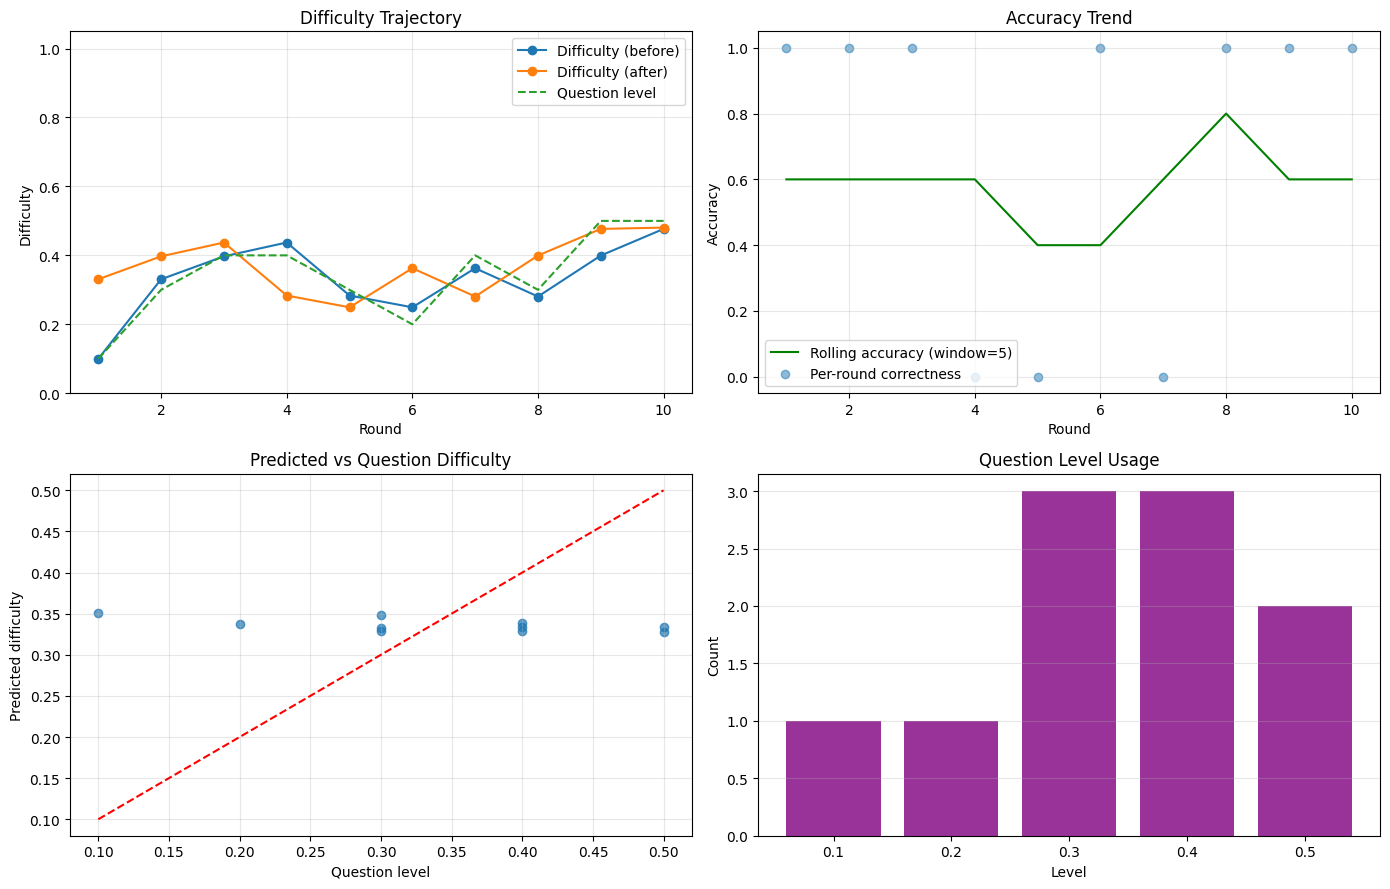

In [16]:
def analyze_history(history):
    if not history:
        print("No history to analyze.")
        return

    accuracies = np.array([1 if h["correct"] else 0 for h in history], dtype=float)
    start_difficulty = history[0]["difficulty_before"]
    end_difficulty = history[-1]["difficulty_after"]
    mean_level = np.mean([h["question_level"] for h in history])
    changes = np.array([h["difficulty_after"] - h["difficulty_before"] for h in history], dtype=float)

    print("=== Quiz Analysis ===")
    print(f"Rounds: {len(history)}")
    print(f"Accuracy: {np.mean(accuracies) * 100:.2f}%")
    print(f"Start difficulty: {start_difficulty:.2f}")
    print(f"End difficulty: {end_difficulty:.2f}")
    print(f"Average question level: {mean_level:.2f}")
    print(f"Average difficulty change per round: {np.mean(changes):.4f}")

def plot_quiz_analysis(history, pretrain_history=None):
    if not history:
        print("No history to plot.")
        return

    rounds = np.array([h["round"] for h in history])
    diff_before = np.array([h["difficulty_before"] for h in history])
    diff_after = np.array([h["difficulty_after"] for h in history])
    question_levels = np.array([h["question_level"] for h in history])
    predicted = np.array([h["predicted_diff"] for h in history])
    correct_arr = np.array([1 if h["correct"] else 0 for h in history], dtype=float)

    window = min(5, len(correct_arr))
    kernel = np.ones(window) / window
    rolling_acc = np.convolve(correct_arr, kernel, mode="same")

    fig, axs = plt.subplots(2, 2, figsize=(14, 9))

    axs[0, 0].plot(rounds, diff_before, marker="o", label="Difficulty (before)")
    axs[0, 0].plot(rounds, diff_after, marker="o", label="Difficulty (after)")
    axs[0, 0].plot(rounds, question_levels, linestyle="--", label="Question level")
    axs[0, 0].set_title("Difficulty Trajectory")
    axs[0, 0].set_xlabel("Round")
    axs[0, 0].set_ylabel("Difficulty")
    axs[0, 0].set_ylim(0, 1.05)
    axs[0, 0].legend()
    axs[0, 0].grid(True, alpha=0.3)

    axs[0, 1].plot(rounds, rolling_acc, color="green", label=f"Rolling accuracy (window={window})")
    axs[0, 1].scatter(rounds, correct_arr, alpha=0.5, label="Per-round correctness")
    axs[0, 1].set_title("Accuracy Trend")
    axs[0, 1].set_xlabel("Round")
    axs[0, 1].set_ylabel("Accuracy")
    axs[0, 1].set_ylim(-0.05, 1.05)
    axs[0, 1].legend()
    axs[0, 1].grid(True, alpha=0.3)

    axs[1, 0].scatter(question_levels, predicted, alpha=0.7)
    min_v = float(min(question_levels.min(), predicted.min()))
    max_v = float(max(question_levels.max(), predicted.max()))
    axs[1, 0].plot([min_v, max_v], [min_v, max_v], linestyle="--", color="red")
    axs[1, 0].set_title("Predicted vs Question Difficulty")
    axs[1, 0].set_xlabel("Question level")
    axs[1, 0].set_ylabel("Predicted difficulty")
    axs[1, 0].grid(True, alpha=0.3)

    unique_levels, counts = np.unique(question_levels, return_counts=True)
    axs[1, 1].bar(unique_levels.astype(str), counts, color="purple", alpha=0.8)
    axs[1, 1].set_title("Question Level Usage")
    axs[1, 1].set_xlabel("Level")
    axs[1, 1].set_ylabel("Count")
    axs[1, 1].grid(True, axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

    if pretrain_history:
        epochs = np.array([h["epoch"] for h in pretrain_history])
        errors = np.array([h["abs_error"] for h in pretrain_history])

        plt.figure(figsize=(10, 4))
        plt.plot(epochs, errors, linewidth=1.2)
        plt.title("Pretraining Absolute Error Curve")
        plt.xlabel("Epoch")
        plt.ylabel("|predicted - target|")
        plt.grid(True, alpha=0.3)
        plt.show()

# Example usage:
model, history, pretrain_history = run_quiz(rounds=10, lr=0.1, do_pretrain=True)
analyze_history(history)
plot_quiz_analysis(history, pretrain_history)